In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df=pd.read_csv('C:/Users/Haseeb/Downloads/internship/task 2/Mall_Customers.csv')

In [15]:
# EDA Starts here#

In [16]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [17]:
df.shape

(200, 5)

In [18]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [20]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [21]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [ ]:
#KMeans start here

In [22]:
from sklearn.cluster import KMeans


In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)

In [27]:
y_kmeans = kmeans.fit_predict(X_scaled)

C:\Users\Haseeb\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [28]:
df['Cluster'] = y_kmeans

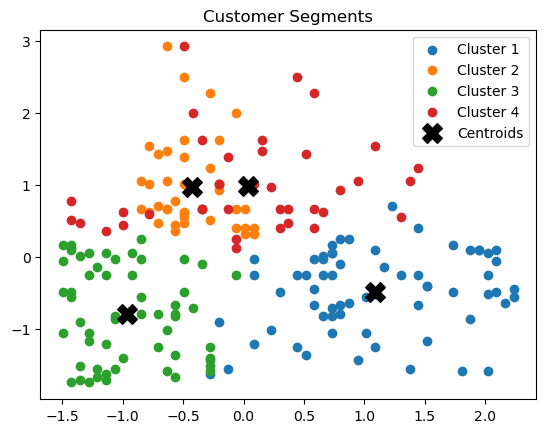

In [29]:
plt.scatter(X_scaled[y_kmeans == 0, 0], X_scaled[y_kmeans == 0, 1], label='Cluster 1')
plt.scatter(X_scaled[y_kmeans == 1, 0], X_scaled[y_kmeans == 1, 1], label='Cluster 2')
plt.scatter(X_scaled[y_kmeans == 2, 0], X_scaled[y_kmeans == 2, 1], label='Cluster 3')
plt.scatter(X_scaled[y_kmeans == 3, 0], X_scaled[y_kmeans == 3, 1], label='Cluster 4')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='black', marker='X', label='Centroids')

plt.legend()
plt.title("Customer Segments")
plt.show()

In [ ]:
#PCA starts here

In [30]:
from sklearn.decomposition import PCA

In [31]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [33]:
clusters = kmeans.fit_predict(X_scaled)

C:\Users\Haseeb\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [37]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2']) #PC1 stands for Principal component 1 and PC2 stands for principal component 2
pca_df['Cluster'] = clusters

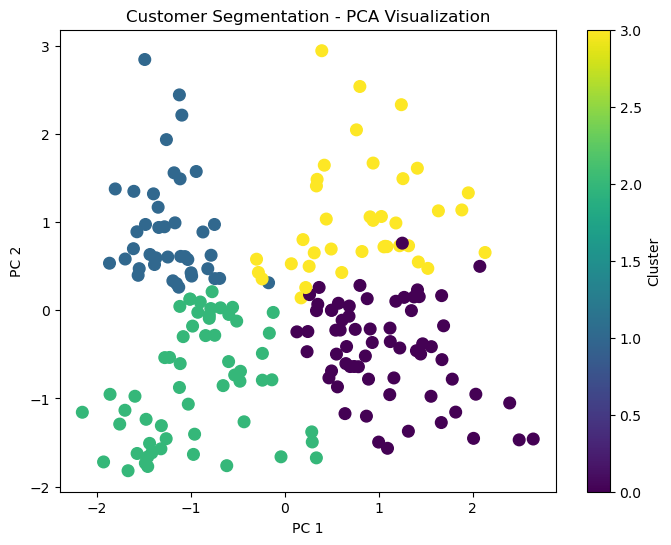

In [38]:
plt.figure(figsize=(8,6))
plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['Cluster'],
    cmap='viridis',
    s=70
)

plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('Customer Segmentation - PCA Visualization')
plt.colorbar(label='Cluster')
plt.show()